<a href="https://colab.research.google.com/github/adaleidman/Data_Science_Project_AL/blob/main/DataCollectionAL%2BProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Data Collection
# Install libraries

!pip install yfinance pandas numpy

In [2]:
# Import

import yfinance as yf
import pandas as pd
import numpy as np
import os

In [3]:
# Download the S&P 500 data

end = pd.Timestamp.today().normalize()
start = end - pd.DateOffset(years=15)

df = yf.download("^GSPC", start=start, end=end, auto_adjust=True, progress=False)

# flatten columns if needed, keep the five we want
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df.rename(columns=str.title)[["Open", "High", "Low", "Close", "Volume"]]
df.index.name = "Date"

print("Downloaded", len(df), "rows, from", df.index.min().date(), "to", df.index.max().date())
df.head()

Downloaded 3771 rows, from 2011-06-15 to 2026-06-12


Price,Open,High,Low,Close,Volume
Date,,,,,
2011-06-15,1287.869995,1287.869995,1261.900024,1265.420044,4070500000
2011-06-16,1265.530029,1274.109985,1258.069946,1267.640015,3846250000
2011-06-17,1268.579956,1279.819946,1267.400024,1271.500000,4916460000
2011-06-20,1271.500000,1280.420044,1267.560059,1278.359985,3464660000
2011-06-21,1278.400024,1297.619995,1278.400024,1295.520020,4056150000


In [4]:
# Save the raw data

os.makedirs("data/raw", exist_ok=True)
df.to_csv("data/raw/sp500_raw.csv")
print("Saved data/raw/sp500_raw.csv")

Saved data/raw/sp500_raw.csv


In [6]:
# Returns

df["return"] = df["Close"].pct_change()
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

In [7]:
# Moving averages (trend)

for w in (10, 20, 50):
    df[f"sma_{w}"] = df["Close"].rolling(w).mean()
df["ema_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["ema_26"] = df["Close"].ewm(span=26, adjust=False).mean()


In [8]:
# RSI (momentum)

delta = df["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)
avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
df["rsi_14"] = 100 - 100 / (1 + avg_gain / avg_loss)

In [9]:
# MACD (trend/momentum)

df["macd"] = df["ema_12"] - df["ema_26"]
df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()
df["macd_hist"] = df["macd"] - df["macd_signal"]

In [10]:
# Bollinger Bands (volatility)

mid = df["Close"].rolling(20).mean()
std = df["Close"].rolling(20).std()
df["bb_upper"] = mid + 2 * std
df["bb_lower"] = mid - 2 * std
df["bb_width"] = (df["bb_upper"] - df["bb_lower"]) / mid

In [11]:
# ATR and momentum

prev_close = df["Close"].shift(1)
tr = pd.concat([df["High"] - df["Low"],
                (df["High"] - prev_close).abs(),
                (df["Low"] - prev_close).abs()], axis=1).max(axis=1)
df["atr_14"] = tr.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
df["momentum_10"] = df["Close"] - df["Close"].shift(10)

In [12]:
# The prediction targets

df["next_return"] = df["Close"].pct_change().shift(-1)          # tomorrow's return
df["target_up"] = (df["Close"].shift(-1) > df["Close"]).astype(int)  # 1 = up, 0 = down

In [13]:
# Clean up and check

df = df.dropna()   # remove warm-up rows and the last row (no future target)
print("Final shape:", df.shape)
print("Up days:", round(df["target_up"].mean() * 100, 1), "%")
df.head()

Final shape: (3721, 23)
Up days: 54.6 %


Price,Open,High,Low,Close,Volume,return,log_return,sma_10,sma_20,sma_50,...,macd,macd_signal,macd_hist,bb_upper,bb_lower,bb_width,atr_14,momentum_10,next_return,target_up
Date,,,,,,,,,,,,,,,,,,,,,
2011-08-24,1162.160034,1178.560059,1156.300049,1177.599976,5315310000,0.013120,0.013035,1167.054004,1193.851001,1264.202202,...,-35.098834,-35.430931,0.332097,1309.868828,1077.833174,0.194359,33.402270,56.839966,-0.015566,0
2011-08-25,1176.689941,1190.680054,1155.469971,1159.270020,5748420000,-0.015566,-0.015688,1165.717004,1186.781000,1262.079202,...,-33.537487,-35.052242,1.514756,1292.134025,1081.427974,0.177544,33.531400,-13.369995,0.015122,1
2011-08-26,1158.849976,1181.229980,1135.910034,1176.800049,5035320000,0.015122,0.015008,1165.516003,1181.007001,1260.262402,...,-30.533609,-34.148516,3.614907,1273.940795,1088.073207,0.157381,34.373439,-2.010010,0.028280,1
2011-08-29,1177.910034,1210.280029,1177.910034,1210.079956,4228070000,0.028280,0.027888,1166.075000,1177.164001,1259.034001,...,-25.177374,-32.354287,7.176913,1257.101284,1097.226719,0.135813,34.309620,5.589966,0.002347,1
2011-08-30,1209.760010,1220.099976,1195.770020,1212.920044,4572570000,0.002347,0.002344,1168.091003,1175.107501,1257.725203,...,-20.467413,-29.976912,9.509500,1248.570417,1101.644585,0.125032,33.596787,20.160034,0.004922,1


In [14]:
# Save the finished dataset

os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/sp500_features.csv")
print("Saved data/processed/sp500_features.csv")

Saved data/processed/sp500_features.csv


In [15]:
# 2. Descriptive Statistics

import matplotlib.pyplot as plt
import seaborn as sns


In [16]:
# Descriptive statistics table

desc = df.describe().T          # count, mean, std, min, quartiles, max
desc.to_csv("eda_describe.csv")  # saved for your report
desc.round(3)

,count,mean,std,min,25%,50%,75%,max
Price,,,,,,,,
Open,3721.0,3.259280e+03,1.568328e+03,1097.420,2.033470e+03,2.804350e+03,4.298380e+03,7.605310e+03
High,3721.0,3.276470e+03,1.576181e+03,1125.120,2.044210e+03,2.815100e+03,4.327010e+03,7.620900e+03
Low,3721.0,3.240903e+03,1.559816e+03,1074.770,2.022490e+03,2.789470e+03,4.269690e+03,7.582990e+03
Close,3721.0,3.260018e+03,1.568614e+03,1099.230,2.035940e+03,2.802600e+03,4.300170e+03,7.609780e+03
Volume,3721.0,4.022913e+09,1.008745e+09,0.000,3.380640e+09,3.810340e+09,4.465360e+09,1.002582e+10
return,3721.0,1.000000e-03,1.100000e-02,-0.120,-4.000000e-03,1.000000e-03,6.000000e-03,9.500000e-02
log_return,3721.0,0.000000e+00,1.100000e-02,-0.128,-4.000000e-03,1.000000e-03,6.000000e-03,9.100000e-02
sma_10,3721.0,3.252453e+03,1.562982e+03,1141.441,2.033542e+03,2.800436e+03,4.304289e+03,7.545009e+03
sma_20,3721.0,3.243950e+03,1.556359e+03,1162.775,2.034329e+03,2.791036e+03,4.303688e+03,7.479849e+03


In [17]:
# Data quality + class balance

print("Missing values in total:", df.isna().sum().sum())   # should be 0
print("Trading days:", len(df))
print("Date range:", df.index.min().date(), "to", df.index.max().date())
print("Up days: {:.1f}%   Down days: {:.1f}%".format(
      df['target_up'].mean()*100, (1 - df['target_up'].mean())*100))

Missing values in total: 0
Trading days: 3721
Date range: 2011-08-24 to 2026-06-11
Up days: 54.6%   Down days: 45.4%


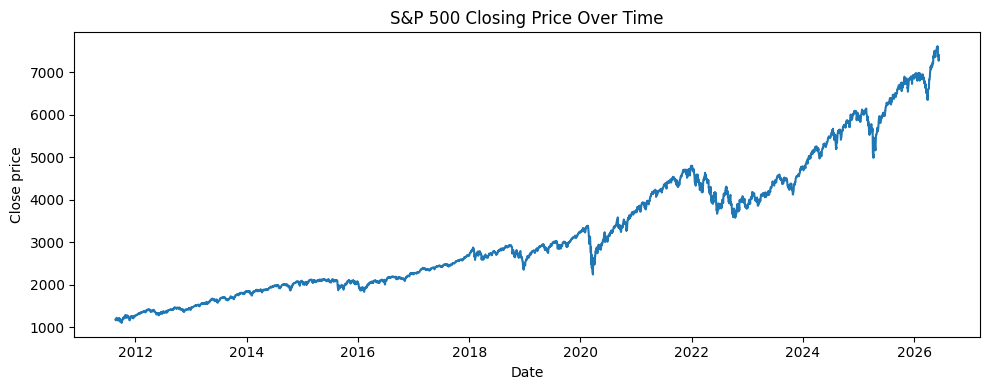

In [18]:
# Closing price over time (shows the upward trend / non-stationarity)

plt.figure(figsize=(10,4))
plt.plot(df.index, df['Close'])
plt.title("S&P 500 Closing Price Over Time")
plt.xlabel("Date"); plt.ylabel("Close price")
plt.tight_layout()
plt.savefig("eda_price.png", dpi=150)
plt.show()

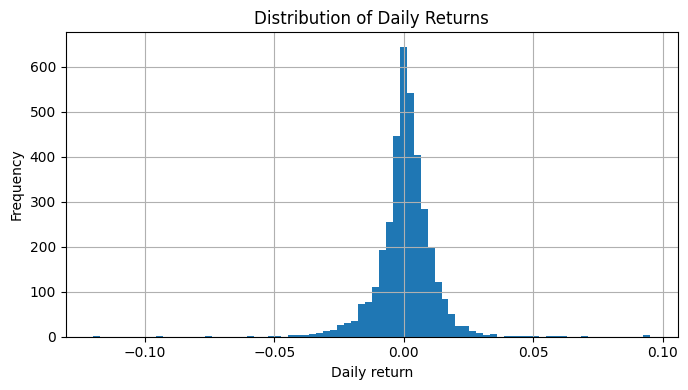

In [19]:
# Distribution of daily returns

plt.figure(figsize=(7,4))
df['return'].hist(bins=80)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily return"); plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("eda_returns.png", dpi=150)
plt.show()

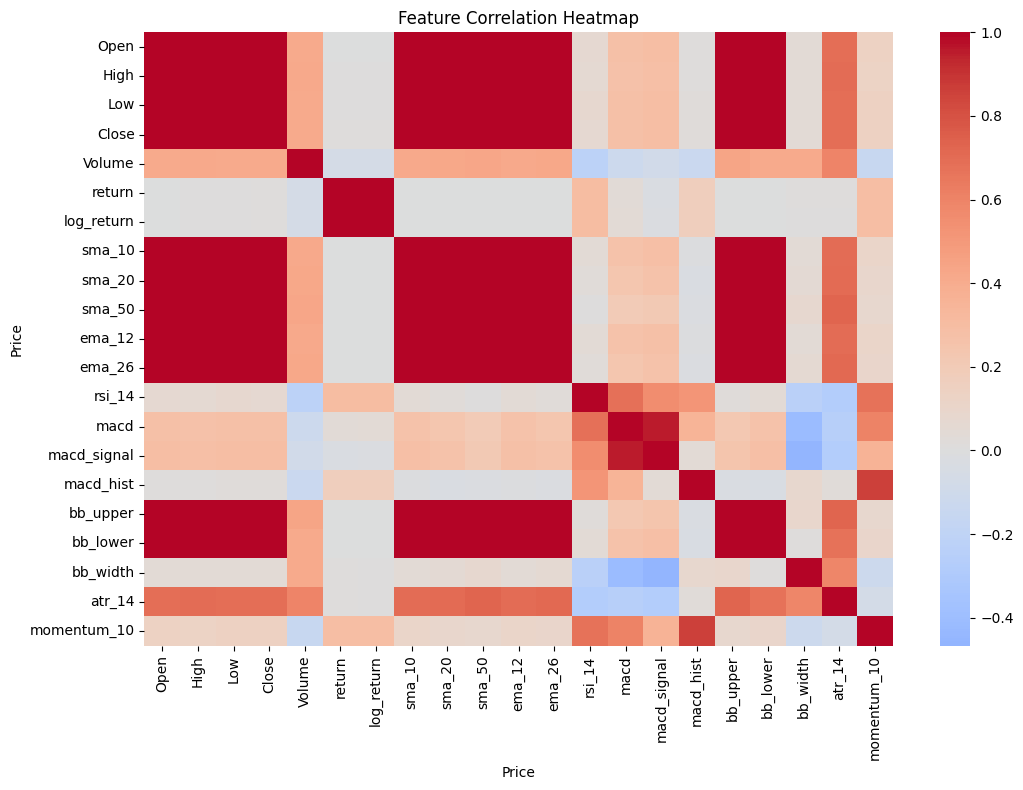

In [20]:
# Feature correlation heatmap (key for your RQ3 — shows the indicators are correlated)

plt.figure(figsize=(11,8))
sns.heatmap(df.drop(columns=['target_up','next_return']).corr(),
            cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("eda_corr.png", dpi=150)
plt.show()

In [21]:
# Download the outputs to keep them

from google.colab import files
for f in ["eda_describe.csv", "eda_price.png", "eda_returns.png", "eda_corr.png"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
# 3. Modelling and Tunning

!pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.2 MB/s eta 0:00:00


In [23]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def metrics_row(name, y_true, y_pred):
    return {"model": name,
            "accuracy":  round(accuracy_score(y_true, y_pred), 4),
            "precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
            "recall":    round(recall_score(y_true, y_pred, zero_division=0), 4),
            "f1":        round(f1_score(y_true, y_pred, zero_division=0), 4)}

In [24]:
# Features and target

DROP_COLS = ["target_up", "next_return"]            # not model inputs
feature_cols = [c for c in df.columns if c not in DROP_COLS]
X = df[feature_cols].astype("float32")
y = df["target_up"].astype("int").values
print("Features:", len(feature_cols), "| samples:", len(X))

Features: 21 | samples: 3721


In [25]:
# Chronological split + scaling (no leakage)

TEST_FRACTION = 0.20
cut = int(len(X) * (1 - TEST_FRACTION))
X_train, X_test = X.iloc[:cut], X.iloc[cut:]
y_train, y_test = y[:cut], y[cut:]

scaler = StandardScaler().fit(X_train)              # fit on TRAIN ONLY
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)
print("Train:", len(X_train), " Test:", len(X_test))

results = []                                        # we collect each model's score here

Train: 2976  Test: 745


In [26]:
# Naive baseline (the score to beat: ~54.6%)

majority = int(round(y_train.mean()))
naive_pred = np.full_like(y_test, majority)
results.append(metrics_row("Naive (majority)", y_test, naive_pred))
results[-1]

{'model': 'Naive (majority)',
 'accuracy': 0.5705,
 'precision': 0.5705,
 'recall': 1.0,
 'f1': 0.7265}

In [29]:
# Random Forest, tuned with TimeSeriesSplit

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.5],
}
rf_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=TimeSeriesSplit(n_splits=5),
    scoring="accuracy", n_jobs=-1, verbose=1)
rf_search.fit(X_train_s, y_train)
print("Best RF params:", rf_search.best_params_)

rf_pred = rf_search.best_estimator_.predict(X_test_s)
results.append(metrics_row("Random Forest (tuned)", y_test, rf_pred))
results[-1]

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best RF params: {'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 200}


{'model': 'Random Forest (tuned)',
 'accuracy': 0.4309,
 'precision': 0.5063,
 'recall': 0.0941,
 'f1': 0.1587}

In [30]:
# Build sequences for the LSTM/GRU (with a chronological validation split)

LOOKBACK = 30
VAL_FRACTION = 0.20

def make_sequences(X2d, y1d, lookback=LOOKBACK):
    Xs, ys = [], []
    for i in range(lookback, len(X2d)):
        Xs.append(X2d[i-lookback:i]); ys.append(y1d[i])
    return np.array(Xs), np.array(ys)

vcut = int(len(X_train_s) * (1 - VAL_FRACTION))     # validation = last part of TRAIN
Xtr_seq, ytr_seq   = make_sequences(X_train_s[:vcut], y_train[:vcut])
Xval_seq, yval_seq = make_sequences(X_train_s[vcut:], y_train[vcut:])
Xte_seq,  yte_seq  = make_sequences(X_test_s, y_test)
n_features = X_train_s.shape[1]
print("Train seq:", Xtr_seq.shape, "| Val:", Xval_seq.shape, "| Test:", Xte_seq.shape)

Train seq: (2350, 30, 21) | Val: (566, 30, 21) | Test: (715, 30, 21)


In [31]:
# Define the model for the tuner

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

def build_model(hp):
    model = keras.Sequential([keras.Input(shape=(LOOKBACK, n_features))])
    rnn = layers.LSTM if hp.Choice("rnn", ["lstm", "gru"]) == "lstm" else layers.GRU
    n_layers = hp.Int("n_layers", 1, 2)
    units    = hp.Choice("units", [32, 64, 128])
    dropout  = hp.Float("dropout", 0.1, 0.4, step=0.1)
    lr       = hp.Choice("lr", [1e-3, 5e-4, 1e-4])
    for i in range(n_layers):
        model.add(rnn(units, return_sequences=(i < n_layers - 1)))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

In [32]:
# Run the search (this is the slow part)

tuner = kt.Hyperband(build_model, objective="val_accuracy", max_epochs=30,
                     factor=3, directory="kt_dir", project_name="rnn_sp500",
                     overwrite=True)
stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5,
                                     restore_best_weights=True)
tuner.search(Xtr_seq, ytr_seq, validation_data=(Xval_seq, yval_seq),
             epochs=30, batch_size=32, callbacks=[stop], verbose=1)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best deep-model params:", best_hp.values)

Trial 90 Complete [00h 00m 27s]
val_accuracy: 0.5053003430366516

Best val_accuracy So Far: 0.5583038926124573
Total elapsed time: 00h 31m 34s
Best deep-model params: {'rnn': 'gru', 'n_layers': 1, 'units': 32, 'dropout': 0.1, 'lr': 0.001, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 3, 'tuner/round': 0}


In [35]:
# Retrain best config with class weights; pick threshold on VALIDATION, score once on TEST
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score

best_model = tuner.hypermodel.build(best_hp)

# class weights so the model stops ignoring the minority class
classes = np.unique(ytr_seq)
cw = compute_class_weight("balanced", classes=classes, y=ytr_seq)
class_weight = {int(c): w for c, w in zip(classes, cw)}

best_model.fit(Xtr_seq, ytr_seq, epochs=40, batch_size=32,
               class_weight=class_weight, verbose=0)      # train on train only

# choose the probability threshold using the VALIDATION set (not the test set!)
val_prob = best_model.predict(Xval_seq).ravel()
best_t, best_acc = 0.5, 0
for t in np.arange(0.35, 0.65, 0.01):
    acc = accuracy_score(yval_seq, (val_prob > t).astype(int))
    if acc > best_acc:
        best_acc, best_t = acc, t
print(f"Chosen threshold (from validation): {best_t:.2f}")

# final, one-shot evaluation on the untouched TEST set
dl_prob = best_model.predict(Xte_seq).ravel()
dl_pred = (dl_prob > best_t).astype(int)
dl_name = best_hp.values["rnn"].upper() + " (tuned)"
results.append(metrics_row(dl_name, yte_seq, dl_pred))
results[-1]

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Chosen threshold (from validation): 0.43
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


{'model': 'GRU (tuned)',
 'accuracy': 0.5399,
 'precision': 0.5747,
 'recall': 0.7451,
 'f1': 0.6489}

In [37]:
# The comparison table

import pandas as pd
comparison = pd.DataFrame(results).set_index("model")
comparison.to_csv("results_comparison.csv")
print("Naive baseline to beat: {:.1f}%".format(y_train.mean()*100))
comparison

Naive baseline to beat: 54.0%


,accuracy,precision,recall,f1
model,,,,
Naive (majority),0.5705,0.5705,1.0000,0.7265
Random Forest (tuned),0.4309,0.5063,0.0941,0.1587
GRU (tuned),0.4448,0.5579,0.1299,0.2107
GRU (tuned),0.5399,0.5747,0.7451,0.6489


In [38]:
# keep only the most recent GRU entry, drop the older duplicate
seen = {}
for row in results:
    seen[row["model"]] = row        # later entry overwrites earlier one
results = list(seen.values())
results

[{'model': 'Naive (majority)',
  'accuracy': 0.5705,
  'precision': 0.5705,
  'recall': 1.0,
  'f1': 0.7265},
 {'model': 'Random Forest (tuned)',
  'accuracy': 0.4309,
  'precision': 0.5063,
  'recall': 0.0941,
  'f1': 0.1587},
 {'model': 'GRU (tuned)',
  'accuracy': 0.5399,
  'precision': 0.5747,
  'recall': 0.7451,
  'f1': 0.6489}]